# Model comparison (micro level)

Density, Time of Presence, Stop duration. Real tracks vs simulated (Unity CSV).

**Input:** DXF with floor plan, folder with real-trajectory CSVs, folder with Unity simulation CSVs.


In [1]:
import sys
from pathlib import Path

for d in [Path.cwd(), Path.cwd() / "model_search"]:
    if (d / "density.py").exists() and str(d) not in sys.path:
        sys.path.insert(0, str(d))
        break

from micro_compare import run_density_comparison, run_top_comparison, run_stop_duration_comparison, run_global_summary
from micro_data import load_micro_data, plot_intro_tracks, plot_density_heatmaps, plot_top_heatmaps

PATH_DXF = r"C:\Users\malko\Desktop\Diploma\Term\bird-dataset-main\model_search\Floor_0.dxf"
PATH_TRAJECTORIES_CSV = "C://Users/malko/Desktop/Diploma/Term/bird-dataset-main/bird-dataset-main/data/normalized_trajectories"
CELL_SIZE_M = 1.0
PATH_UNITY_DXF = r"C:\Users\malko\Desktop\Diploma\Term\bird-dataset-main\model_search\unity_plan_and_tracks.dxf"
PATH_SIMULATION_CSV = r"C:\Users\malko\Nancy_floor0\Assets\StreamingAssets\unity_tracks_bird"


In [2]:
%pip install -q ezdxf pandas matplotlib numpy


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Micro level

Movement metrics per zone: density, time of presence, distribution of stop durations.

**Start of section:** floor plan + tracks + grid (real and simulated).

### Density maps

Visitor density per unit area. Grid 1×1 m (parameter `CELL_SIZE_M`).

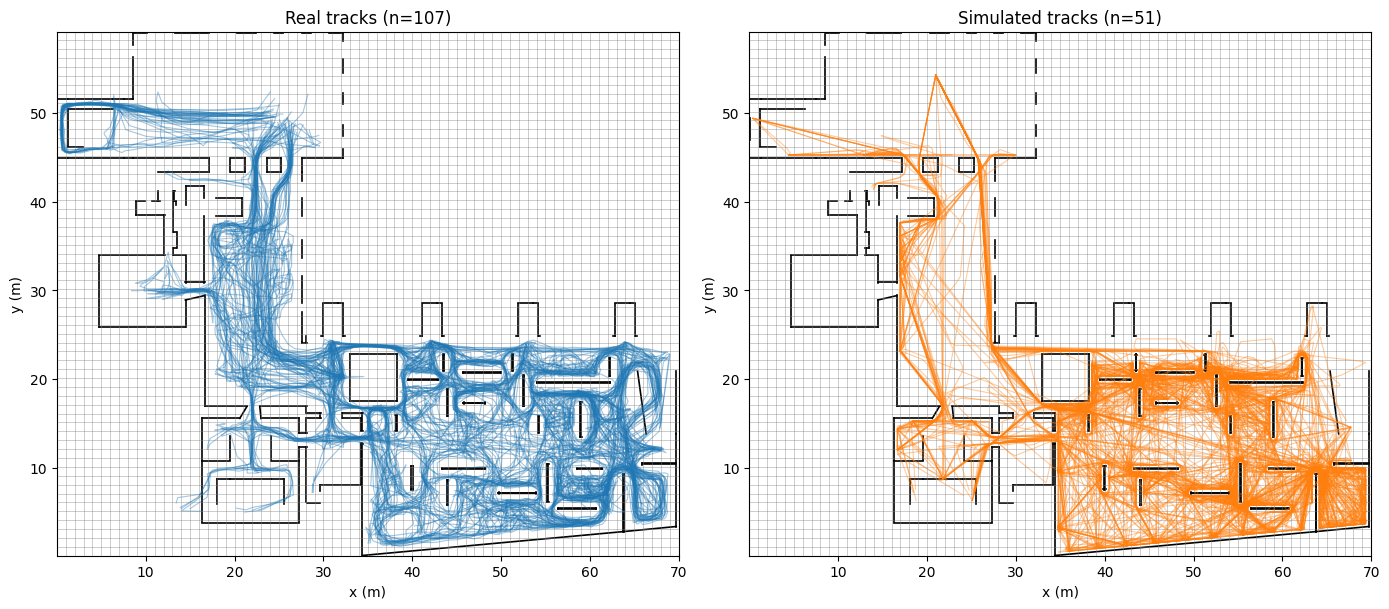

In [3]:
# Intro: floor plan + tracks + grid (real and simulated)
d_real, d_sim, xe, ye, segments, traj_real_m, traj_sim_m = load_micro_data(
    PATH_TRAJECTORIES_CSV, PATH_SIMULATION_CSV, PATH_DXF, PATH_UNITY_DXF, CELL_SIZE_M
)
plot_intro_tracks(segments, xe, ye, traj_real_m, traj_sim_m)

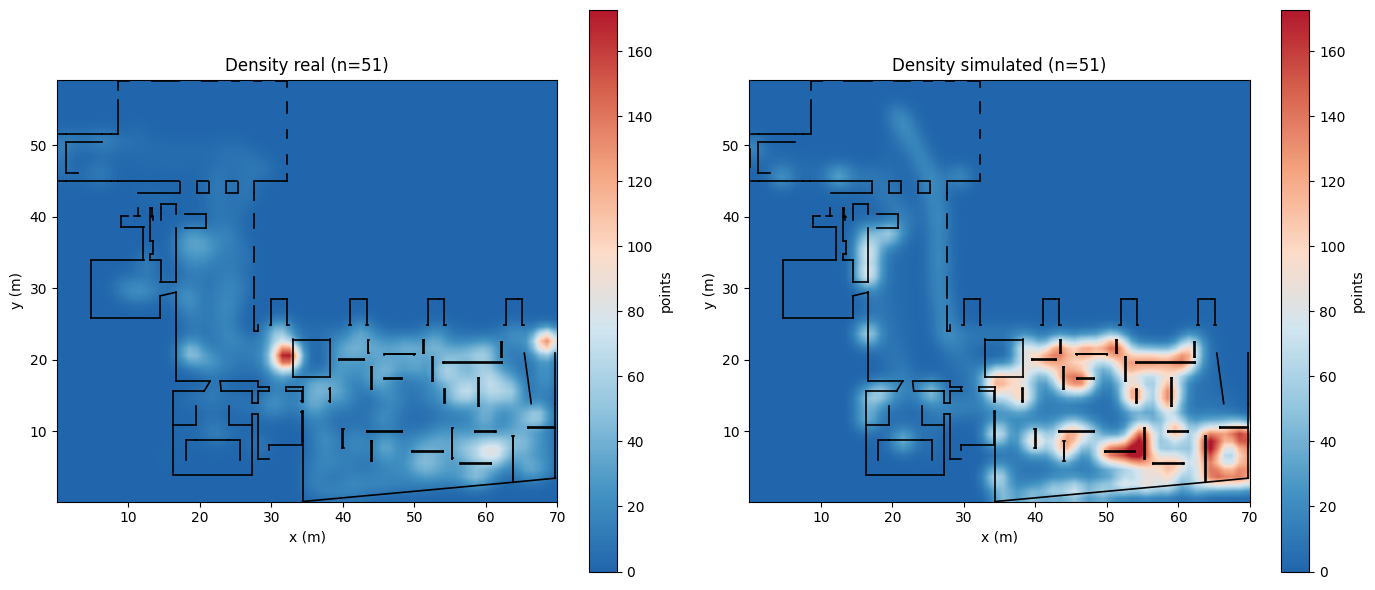

In [4]:
# Density: real and simulated heatmaps
hm_real_smooth, hm_sim_smooth = plot_density_heatmaps(d_real, d_sim, segments, xe, ye)


### Comparison of density maps

Metrics and difference map for the density maps above (real vs simulated).

Correlation:
  Pearson r = 0.5507, Spearman rho = 0.7874 (p = 0.0000)
Errors:
  MAE = 16.2466, RMSE = 30.7479, NMAE = 1.4676


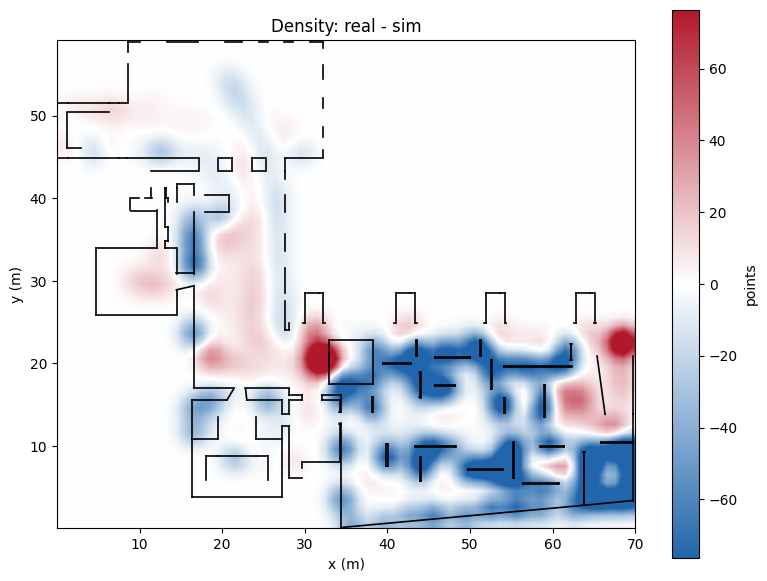

In [5]:
# Comparison of density maps (run after Density cells above)
run_density_comparison(d_real, d_sim, hm_real_smooth, hm_sim_smooth, xe, ye, segments)

### Global totals (Density)

Total density (points) over the floor: real vs simulated.

In [6]:
# Global totals — Density (run after Density comparison above)
density_real = int(d_real["heatmap"].sum())
print("Real:    total density (points) =", density_real)
if d_sim is not None:
    density_sim = int(d_sim["heatmap"].sum())
    print("Simulated: total density (points) =", density_sim)
    print("Ratio sim/real =", round(density_sim / max(density_real, 1), 4))
else:
    print("Simulated: no data")

Real:    total density (points) = 31733
Simulated: total density (points) = 62526
Ratio sim/real = 1.9704


### Time of Presence (ToP)

Time of presence = total time (s) per cell over all agents.

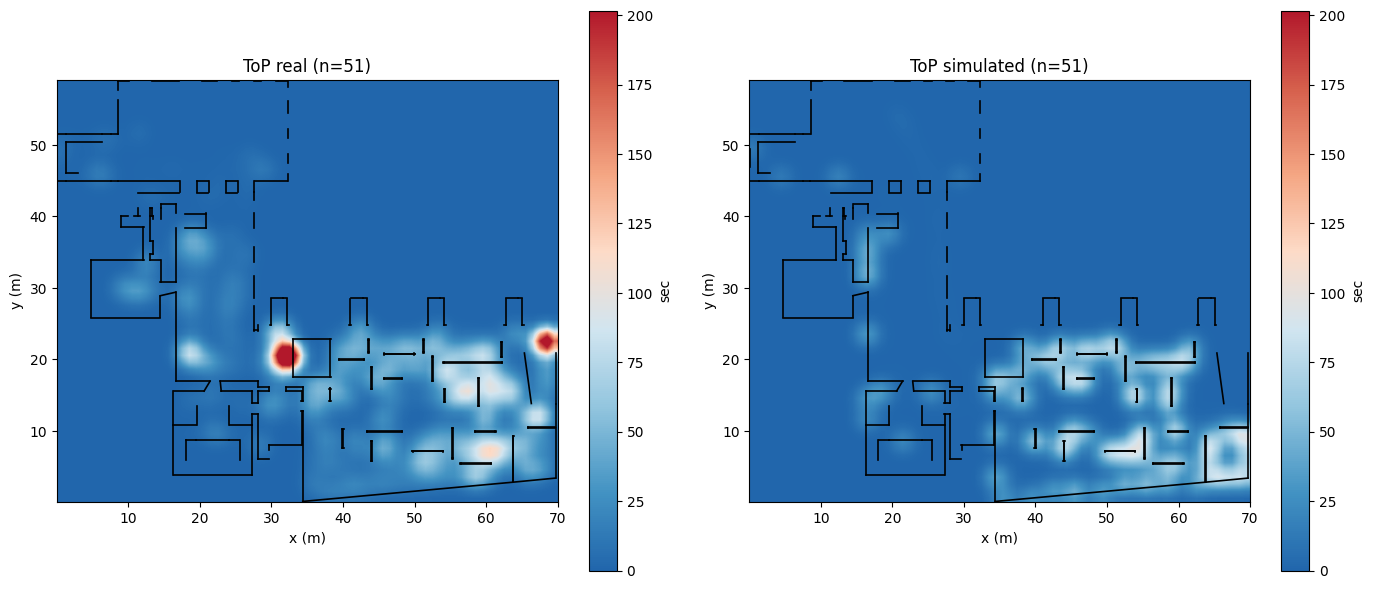

In [7]:
# Time of Presence: same colormap as Density; smoothing and plot
top_real_smooth, top_sim_smooth = plot_top_heatmaps(d_real, d_sim, segments, xe, ye)

### Comparison of ToP maps

Metrics and difference map for the Time of Presence maps above (real vs simulated).

Correlation:
  Pearson r = 0.4214, Spearman rho = 0.7351 (p = 0.0000)
Errors:
  MAE = 10.7615, RMSE = 24.6325, NMAE = 0.7614


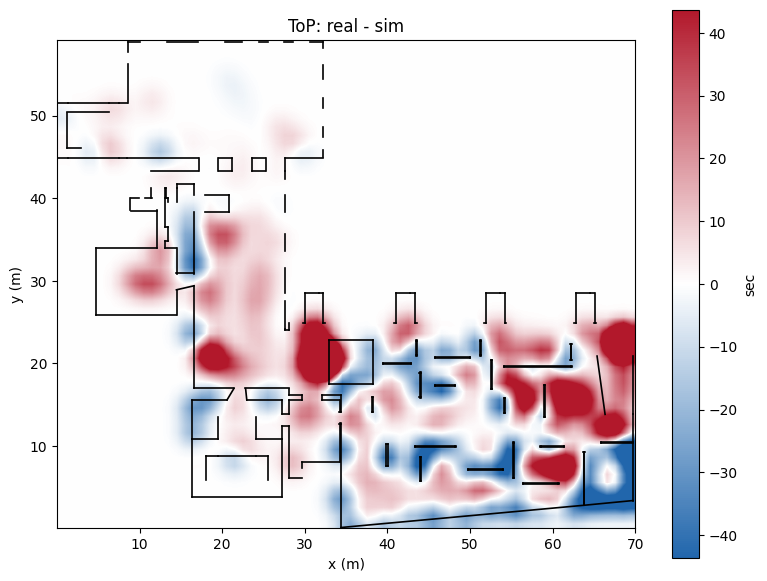

In [8]:
# Comparison of ToP maps (run after ToP cells above)
run_top_comparison(d_real, d_sim, top_real_smooth, top_sim_smooth, xe, ye, segments)

### Global totals (ToP)

Total Time of Presence (seconds) over the floor: real vs simulated.

In [9]:
# Global totals — ToP (run after ToP comparison above)
top_real_sec = float(d_real["top_matrix"].sum())
print("Real:    total ToP =", round(top_real_sec, 1), "s", f"({top_real_sec/60:.1f} min)")
if d_sim is not None:
    top_sim_sec = float(d_sim["top_matrix"].sum())
    print("Simulated: total ToP =", round(top_sim_sec, 1), "s", f"({top_sim_sec/60:.1f} min)")
    print("Ratio sim/real =", round(top_sim_sec / max(top_real_sec, 1e-9), 4))
else:
    print("Simulated: no data")

Real:    total ToP = 39134.0 s (652.2 min)
Simulated: total ToP = 30171.0 s (502.9 min)
Ratio sim/real = 0.771


*(Global totals: Density above after density comparison; ToP above after ToP comparison.)*

In [10]:
# See "Global totals (Density)" and "Global totals (ToP)" in the sections above.

*(Comparison of density maps is above, after Density maps; comparison of ToP maps is above, after ToP maps.)*

In [11]:
# Comparisons are in the sections above (after Density maps and after ToP maps).

### Stop duration distribution

Stop duration stats (run of 2+ points in same cell): mean, median, 75th/90th percentiles, proportion of long stops.

In [12]:
# Stop duration: real vs simulated
run_stop_duration_comparison(d_real, d_sim)

Real:
  n_stops: 4380
  mean: 8.93 s, median: 4.0 s
  75th: 10.0 s, 90th: 18.0 s
  proportion of long stops (>30.0 s): 4.61%
Simulated:
  n_stops: 6206
  mean: 4.86 s, median: 0.61 s
  75th: 8.55 s, 90th: 16.7 s
  proportion of long stops (>30.0 s): 0.50%
Comparison (real vs simulated):
  Mean stop duration: real 8.93 s, sim 4.86 s, diff = 4.07 s
  Median: real 4.0 s, sim 0.61 s, diff = 3.39 s
  Proportion long stops: real 4.61%, sim 0.50%, diff = 4.11%


### Global summary

Summary of real vs simulated comparison for density, ToP, and Stop duration — based on the metrics computed above.

In [13]:
# Global summary from current analysis (run after all cells above)
run_global_summary(d_real, d_sim, hm_real_smooth, hm_sim_smooth, top_real_smooth, top_sim_smooth)

## Global summary: real vs simulated

### Density
- **Correlation:** Pearson r = 0.551, Spearman rho = 0.787 — **strong** agreement.
- **Errors:** MAE = 16.25, NMAE = 1.47 — substantial differences in magnitude.
- **Global total:** density sum real = 31733, sim = 62526, ratio sim/real = 1.970 — **simulation clearly overestimates** overall visits.
- **Targets:** Spearman ρ ≥ 0.7 (spatial pattern) ✓; NMAE ≤ 1.0 (magnitude) ✗.

### Time of Presence (ToP)
- **Correlation:** Pearson r = 0.421, Spearman rho = 0.735 — **strong** agreement.
- **Errors:** MAE = 10.76 s, NMAE = 0.76 — moderate differences.
- **Global total:** ToP sum real = 39134 s (652.2 min), sim = 30171 s (502.9 min), ratio sim/real = 0.771 — **simulation clearly underestimates** presence time.
- **Targets:** Spearman ρ ≥ 0.7 (spatial pattern) ✓; NMAE ≤ 1.0 (magnitude) ✓.

### Stop duration
- **Real:** n_stops = 4380, mean = 8.93 s, median = 4.0 s, proportion of long stops (>30 s) = 4.61%.
- **Simulated:** n_stops = 6206, mean = 4.86 s, median = 0.61 s, proportion long = 0.50%.
- **Comparison:** difference in means = 4.07 s; difference in proportion long = 4.11%.
  Real stops are on average longer — simulation produces more short dwells.
- **Targets:** |mean diff| < 3 s ✗; |proportion long diff| < 10% ✓.

### Recommendations (targets to aim for)
- **Density:** Spearman ρ ≥ 0.7 for good spatial agreement; NMAE ≤ 1.0 for acceptable magnitude errors. Ratio sim/real between 0.8 and 1.2 indicates similar overall activity level.
- **ToP:** Same as density (Spearman ≥ 0.7, NMAE ≤ 1.0). Global ToP ratio near 1.0 means total presence time is well matched.
- **Stop duration:** |Difference in mean stop duration| < 3 s and |difference in proportion of long stops| < 10% suggest similar dwelling behaviour.

---
*Summary generated from metrics computed in the cells above.*